In [13]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [14]:
# We'll use the SMOTE version
df_train = pd.read_csv("diabetes_train_smote_normalized.csv")
df_test = pd.read_csv("diabetes_test_normalized.csv")

In [15]:
X_train = df_train.drop(columns=['class'])
y_train = df_train['class']
X_test = df_test.drop(columns=['class'])
y_test = df_test['class']

In [16]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
le = LabelEncoder()

# 2. Fit and transform the gender column
# We do this for the whole column to ensure consistency
X_train['gender'] = le.fit_transform(X_train['gender'])
X_test['gender'] = le.transform(X_test['gender'])


In [17]:
# Initialize the model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           N       1.00      1.00      1.00        19
           P       1.00      0.88      0.93         8
           Y       0.99      1.00      1.00       139

    accuracy                           0.99       166
   macro avg       1.00      0.96      0.98       166
weighted avg       0.99      0.99      0.99       166



[[ 19   0   0]
 [  0   7   1]
 [  0   0 139]]


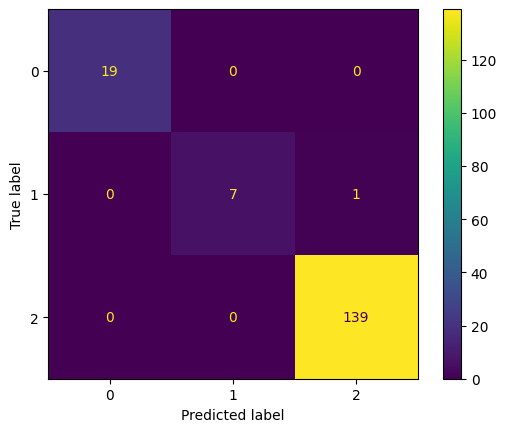

In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

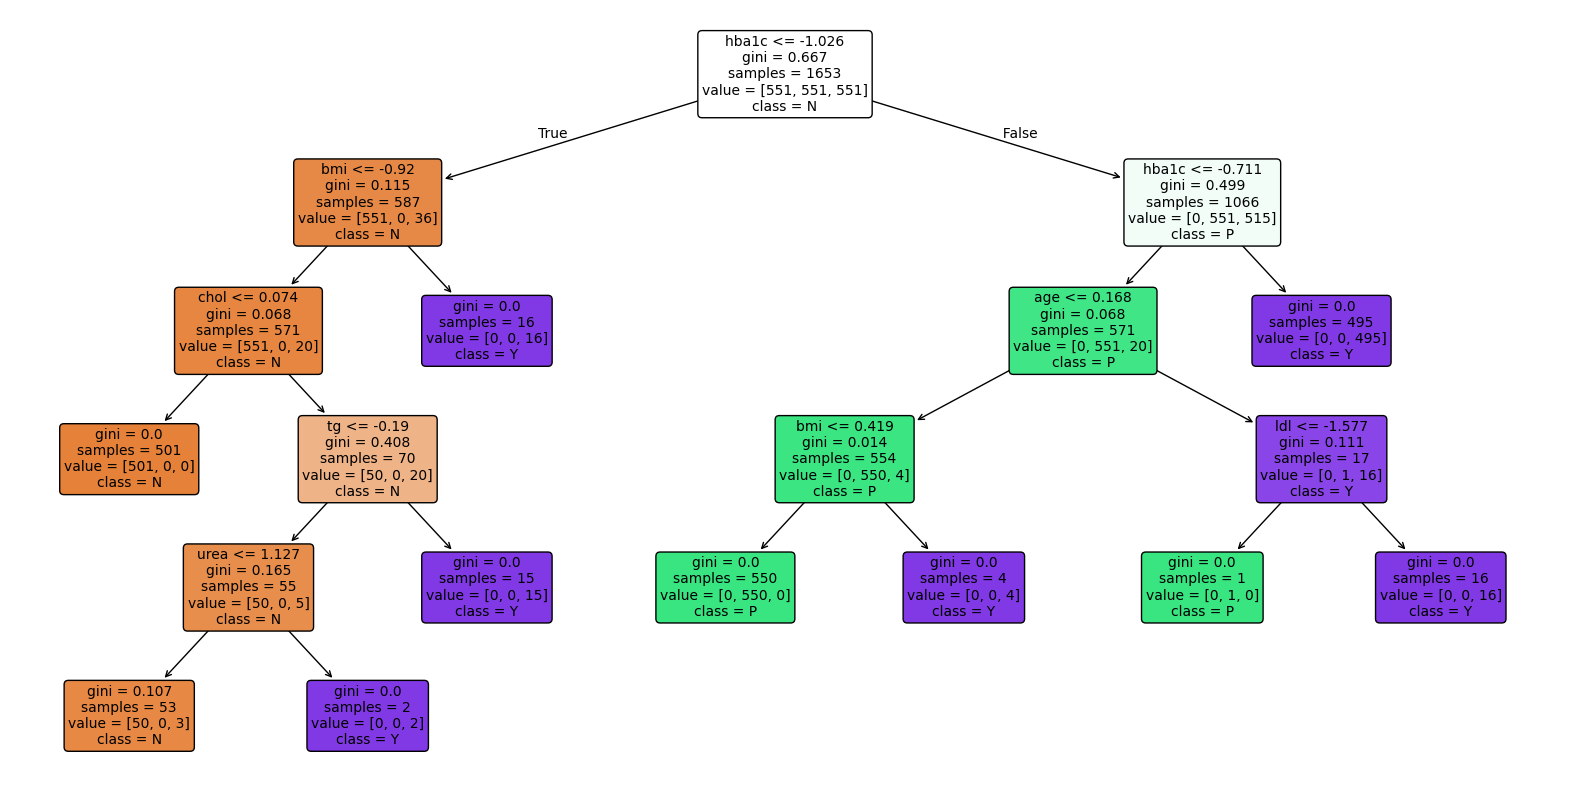

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          class_names=['N', 'P', 'Y'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

With disceretization

In [20]:
from sklearn.preprocessing import KBinsDiscretizer

In [21]:
# Choose which columns to discretize (everything except gender and class)
# We exclude 'gender' (binary) and 'class' (target)
features_to_bin = [col for col in X_train.columns if col != 'gender']

# Initialize the Discretizer
# n_bins=5: creates 5 "buckets" for each feature
# encode='ordinal': turns the values into 0, 1, 2, 3, 4
# strategy='kmeans': uses k-means clustering to find the optimal bin edges
kbins = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')

# Apply to training and testing data
X_train_binned = X_train.copy()
X_test_binned = X_test.copy()

X_train_binned[features_to_bin] = kbins.fit_transform(X_train[features_to_bin])
X_test_binned[features_to_bin] = kbins.transform(X_test[features_to_bin])

# Now use these binned dataframes to train the model
dt_model.fit(X_train_binned, y_train)
y_pred_binned = dt_model.predict(X_test_binned)

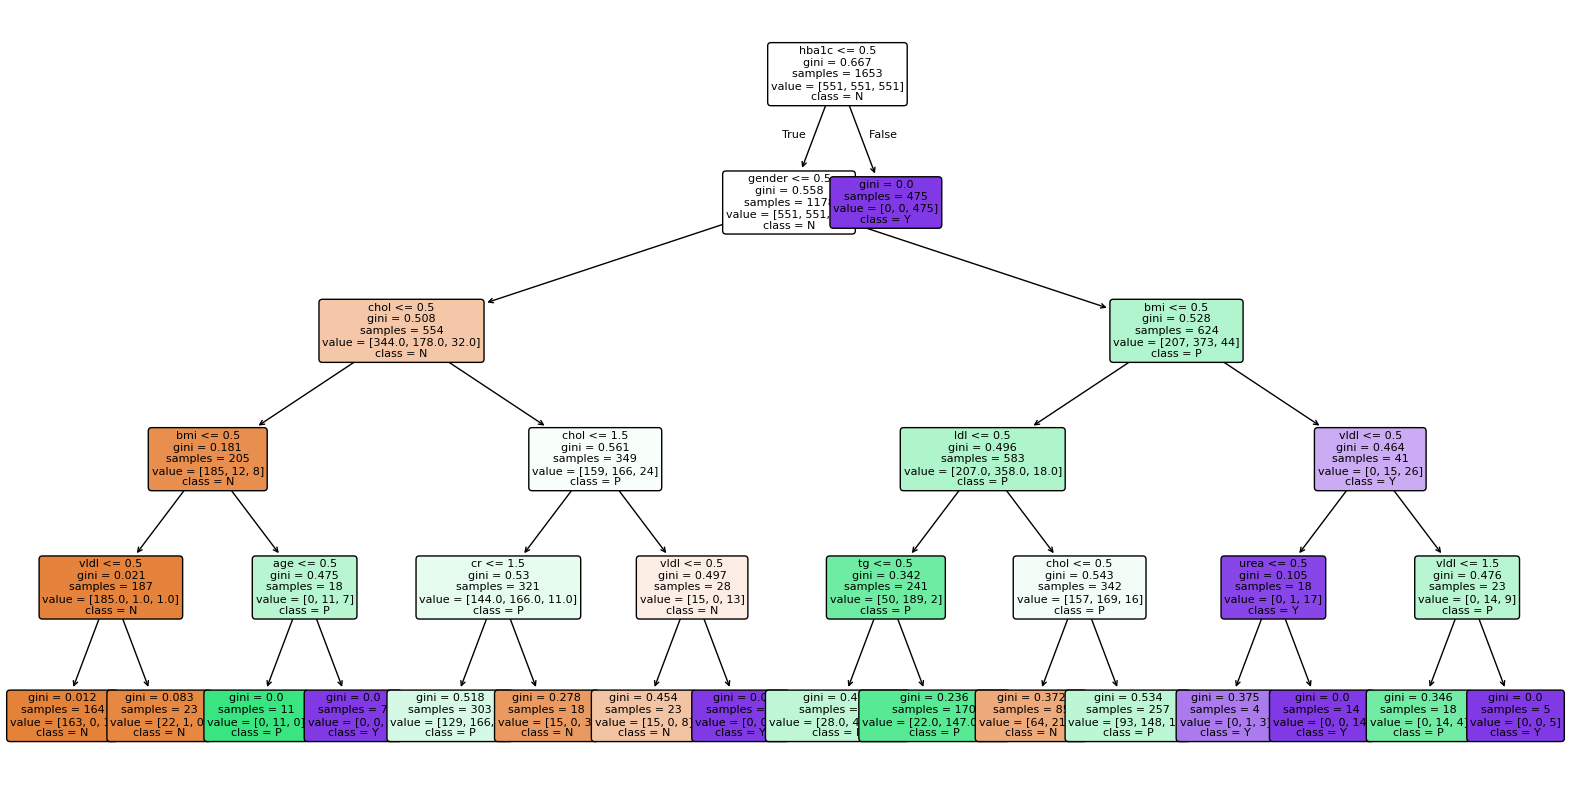

In [22]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train_binned.columns, 
          class_names=['N', 'P', 'Y'], 
          filled=True, 
          rounded=True, 
          fontsize=8)
plt.show()

In [23]:
print("Classification Report:\n", classification_report(y_test, y_pred_binned))

Classification Report:
               precision    recall  f1-score   support

           N       1.00      0.42      0.59        19
           P       0.27      0.88      0.41         8
           Y       0.99      0.94      0.97       139

    accuracy                           0.88       166
   macro avg       0.75      0.75      0.66       166
weighted avg       0.96      0.88      0.90       166



[[  8  11   0]
 [  0   7   1]
 [  0   8 131]]


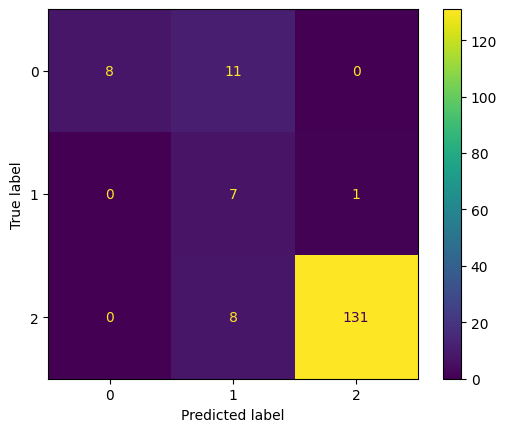

In [24]:
cm = confusion_matrix(y_test, y_pred_binned)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

using the original cleaned dataset before normalization, relying on 'class weight' attribute to ensure balance in classes

In [25]:
df = pd.read_csv("diabetes_milestone1_cleaned.csv")

since we r using the original dataset (before smote which is splitted), we split data into training and testing

In [26]:
from sklearn.model_selection import train_test_split

# 1. Split data
X = df.drop(columns=['CLASS'])
y = df['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
# 2. Create Decision Tree with class weights
model = DecisionTreeClassifier(
    class_weight='balanced',   # key line
    max_depth=5,               # control overfitting
    random_state=42
)

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender']).astype(float)
X_test['Gender'] = le.transform(X_test['Gender']).astype(float)
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


notice the results of the accuracy, this indicates overfitting happened

In [30]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.88      0.93         8
           2       0.99      1.00      1.00       139

    accuracy                           0.99       166
   macro avg       1.00      0.96      0.98       166
weighted avg       0.99      0.99      0.99       166



[[ 19   0   0]
 [  0   7   1]
 [  0   0 139]]


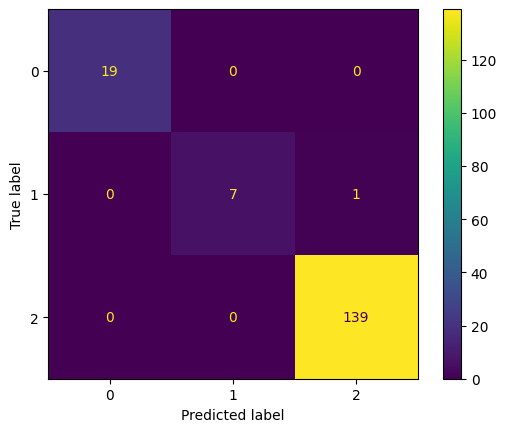

In [31]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

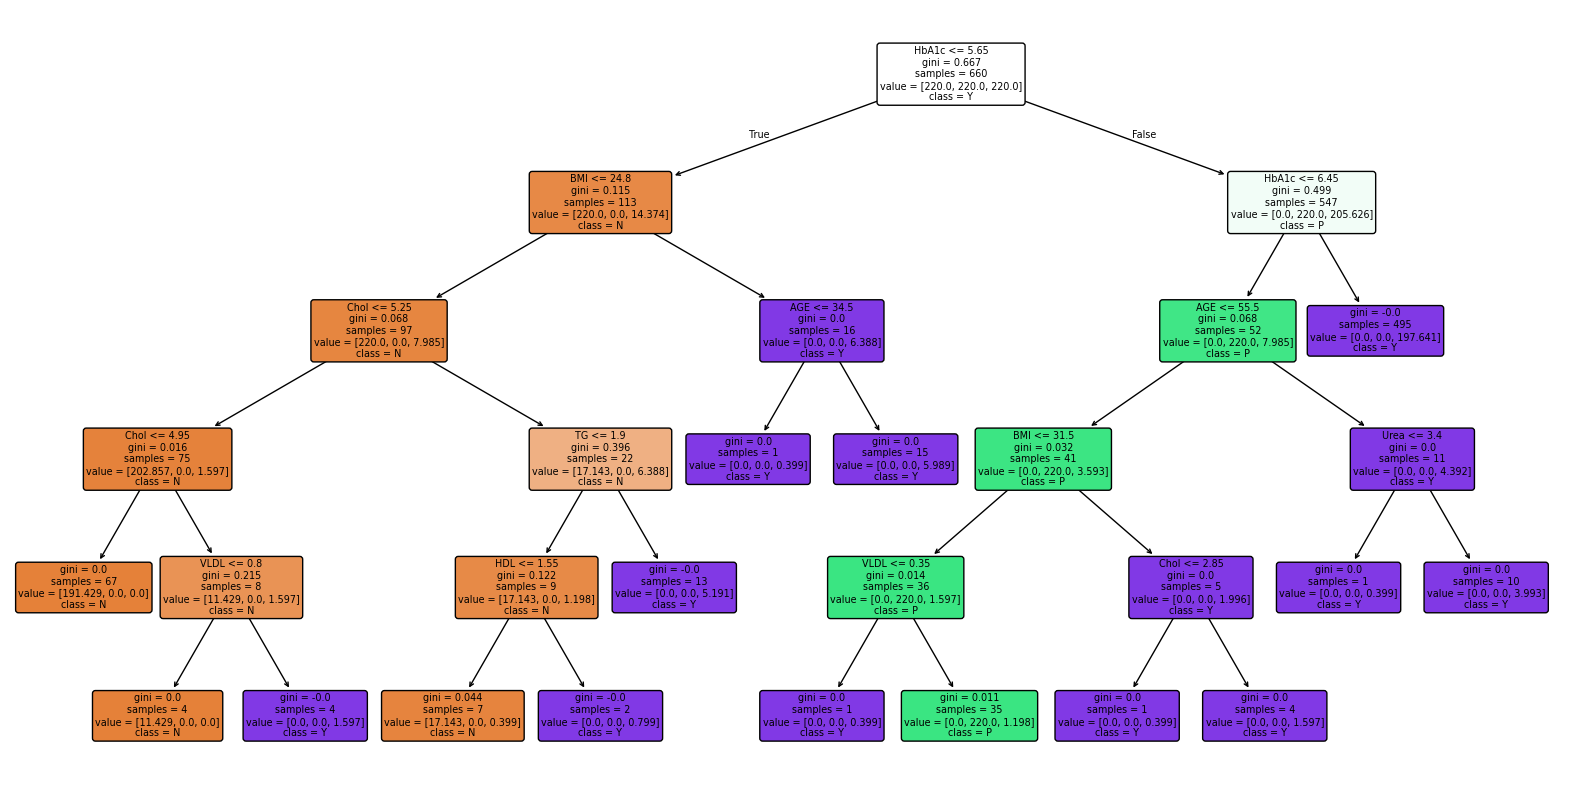

In [32]:

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['N', 'P', 'Y'], 
    filled=True,
    rounded=True
)

plt.show()

now same approach but with discretized features (the correct approach)

In [33]:
features_to_bin = [col for col in X_train.columns if col != 'gender']
kbins = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
X_train_binned = X_train.copy()
X_test_binned = X_test.copy()


X_train_binned[features_to_bin] = kbins.fit_transform(X_train[features_to_bin])
X_test_binned[features_to_bin] = kbins.transform(X_test[features_to_bin])



c:\Users\Hams\Downloads\Data Mining\Assignments\.venv\lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Hams\Downloads\Data Mining\Assignments\.venv\lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [ ]:
# 3. Train
model.fit(X_train_binned, y_train)

# 4. Predict
y_pred_binned = model.predict(X_test_binned)

# 5. Evaluate
print(classification_report(y_test, y_pred_binned))

[[  6  13   0]
 [  0   7   1]
 [  0   4 135]]
              precision    recall  f1-score   support

           0       1.00      0.32      0.48        19
           1       0.29      0.88      0.44         8
           2       0.99      0.97      0.98       139

    accuracy                           0.89       166
   macro avg       0.76      0.72      0.63       166
weighted avg       0.96      0.89      0.90       166



[[  6  13   0]
 [  0   7   1]
 [  0   4 135]]


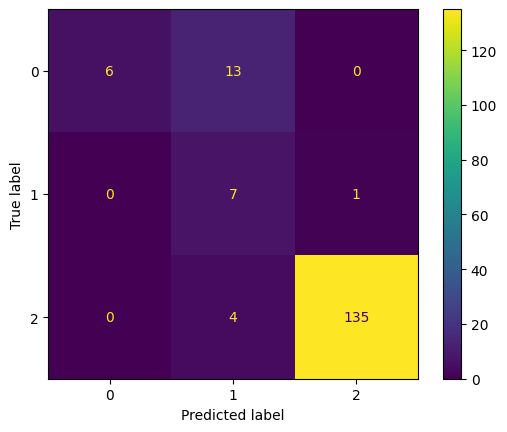

In [36]:
cm = confusion_matrix(y_test, y_pred_binned)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

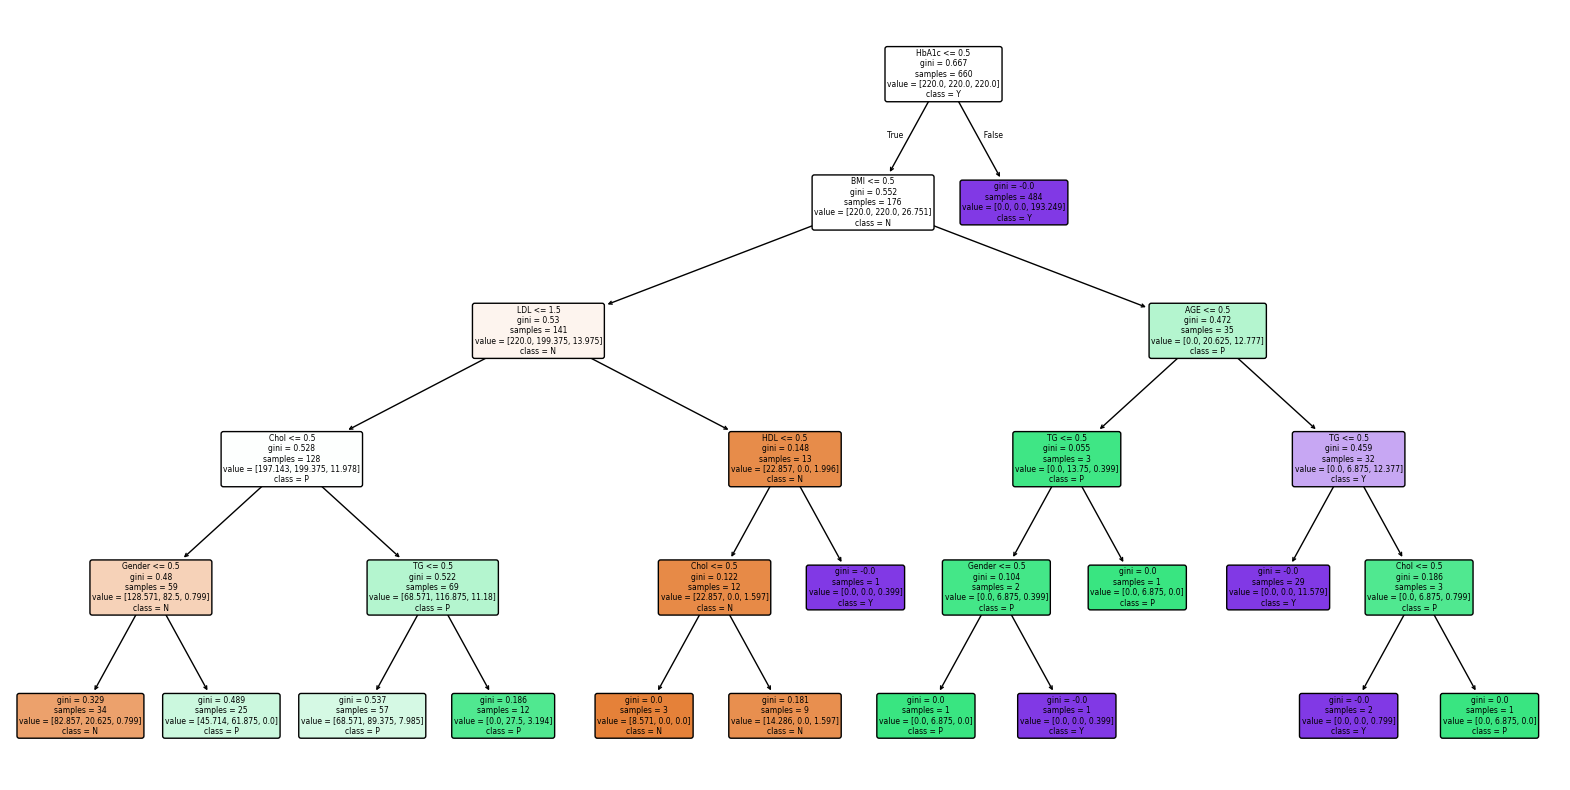

In [37]:

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['N', 'P', 'Y'],  # change if needed
    filled=True,
    rounded=True
)

plt.show()